In [ ]:
import pandas as pd
import numpy as np
import pyomo.environ as pyo
import matplotlib.pyplot as plt

!pip install pyomo
# and some LP/MILP solver available on your system

!apt-get update
!apt-get install -y coinor-cbc


# Day and starting hour that will be analysed (24 hour perido)

In [ ]:
DAY = 30+31+30+31-2+14+31+28
START_HOUR = 0
df_merged = pd.read_excel('final_dataset_MILP.xlsx')

# Run MILP on the defined period

CBC available?  True
GLPK available? False
HiGHS available? True
Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
MIP has 580 rows; 575 cols; 1342 nonzeros; 71 integer variables (71 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+01]
  Cost    [3e-01, 2e+00]
  Bound   [1e+00, 3e+01]
  RHS     [8e-03, 3e+01]
Presolving model
332 rows, 518 cols, 1034 nonzeros 0s
246 rows, 432 cols, 814 nonzeros 0s
230 rows, 345 cols, 659 nonzeros 0s
230 rows, 345 cols, 659 nonzeros 0s
Presolve reductions: rows 230(-350); columns 345(-230); nonzeros 659(-683) 

Solving MIP model with:
   230 rows
   345 cols (52 binary, 0 integer, 0 implied int., 293 continuous, 0 domain fixed)
   659 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;


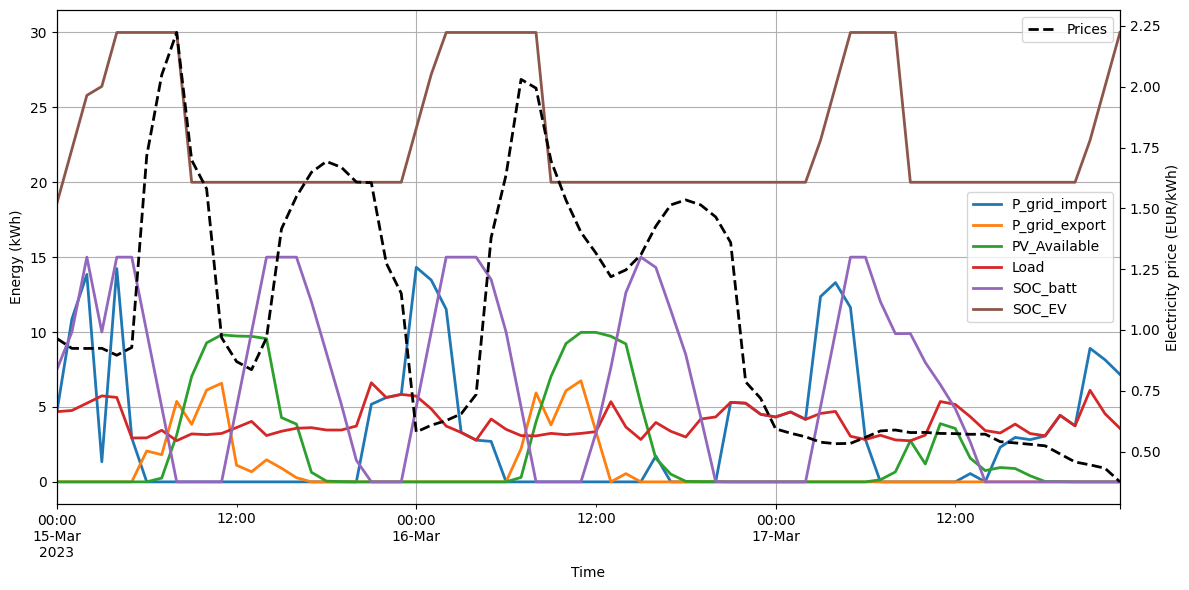

Total money spent in that period: 89.8892  sek


In [ ]:
start_idx = DAY * 24 + START_HOUR   # day * hour

df_day = df_merged.iloc[start_idx : start_idx + 24 * 3].copy()


df_day.head()
#### -----------------Case for no PV nor Battery --------------#####

df_no_pv_no_batt = df_day.copy()
df_no_pv_no_batt['EV_assumption'] = 0.0
df_no_pv_no_batt.loc[df_no_pv_no_batt['utc_timestamp'].dt.hour.between(5, 8), 'EV_assumption'] = 3.6
#### ------------------------------ MILP ------------------------###


# Ensure sorted and continuous hourly index
df_day = df_day.sort_values('utc_timestamp').reset_index(drop=True)

# Build simple dicts keyed by time index (0..N-1)
T_index = df_day.index.tolist()

demand = df_day['Appliances_load'].to_dict()
pv_gen = df_day['pv'].to_dict()
price_buy = df_day['price_EUR_kWh'].to_dict()
EV_connected = df_day['EV_connected'].to_dict()
is_9am = df_day['is_9am'].to_dict()


# If you want a different sell price (e.g. 80% of buy):
sell_factor = 0.8
price_sell = {t: sell_factor * price_buy[t] for t in T_index}

initial_price = demand[0] * price_buy[0]





# -----------------------
# 1. Create model & set
# -----------------------

model = pyo.ConcreteModel()

model.T = pyo.Set(initialize=T_index, ordered=True)  # time steps (0..N-1)





# -----------------------
# 2. Parameters
# -----------------------

# Data from pandas
model.demand = pyo.Param(model.T, initialize=demand)      # kWh
model.pv      = pyo.Param(model.T, initialize=pv_gen)     # kWh
model.price_buy  = pyo.Param(model.T, initialize=price_buy)   # EUR/kWh
model.price_sell = pyo.Param(model.T, initialize=price_sell)  # EUR/kWh

# Tech parameters (you choose these)
Cap_batt   = 15.0   # kWh
P_batt_max = 5.0    # kW (kWh per hour)
Batt_init = Cap_batt/2   # initial SoC

Cap_EV = 30         # kWh
P_EV_max = 3.6      # kW (kWh per hour)
EV_init     = 0.5 * Cap_EV  # initial SoC

#-----------------  CHECK PARAMETERS BECAUSE OF SOC ASSUMPTIONS ----------------------------------###

model.Cap_batt   = pyo.Param(initialize=Cap_batt)
model.P_batt_max = pyo.Param(initialize=P_batt_max)
model.Batt_init     = pyo.Param(initialize=Batt_init)
model.Init_import = pyo.Param(initialize=demand[0])

model.Cap_EV   = pyo.Param(initialize=Cap_EV)
model.P_EV_max = pyo.Param(initialize=P_EV_max)
model.EV_init     = pyo.Param(initialize=EV_init)

# Grid power limit (optional, choose something large enough)
P_grid_max = 20 #kW
model.P_grid_max = pyo.Param(initialize=P_grid_max)

#EV connection
model.EV_connected = pyo.Param(
    model.T,
    initialize=EV_connected,
    within=pyo.Binary
)

#EV charging requirements
model.is_9am = pyo.Param(
    model.T,
    initialize=is_9am,
    within=pyo.Binary
)






# -----------------------
# 3. Decision variables
# -----------------------

model.P_grid_import = pyo.Var(model.T, domain=pyo.NonNegativeReals)
model.P_grid_export = pyo.Var(model.T, domain=pyo.NonNegativeReals)

model.P_batt_ch  = pyo.Var(model.T, domain=pyo.NonNegativeReals)
model.P_batt_dis = pyo.Var(model.T, domain=pyo.NonNegativeReals)
model.SOC_batt = pyo.Var(model.T, domain=pyo.NonNegativeReals, bounds=(0, Cap_batt))

model.P_EV_ch  = pyo.Var(model.T, domain=pyo.NonNegativeReals)
model.SOC_EV = pyo.Var(model.T, domain=pyo.NonNegativeReals, bounds=(0, Cap_EV))


# (Optional) binaries to avoid simultaneous buy & sell
model.y_buy = pyo.Var(model.T, domain=pyo.Binary)






# -----------------------
# 4. Constraints
# -----------------------

# 4.1 Energy balance
def energy_balance_rule(m, t):
    return ( m.P_grid_import[t]
           + m.P_batt_dis[t]
             + m.pv[t]
           ==
             m.demand[t]
           + m.P_batt_ch[t]
           + m.P_EV_ch[t]
           + m.P_grid_export[t]
    )

model.EnergyBalance = pyo.Constraint(model.T, rule=energy_balance_rule)

# 4.2 Battery power limits
def batt_ch_limit_rule(m, t):
    return m.P_batt_ch[t] <= m.P_batt_max

def batt_dis_limit_rule(m, t):
    return m.P_batt_dis[t] <= m.P_batt_max

model.BattChLimit  = pyo.Constraint(model.T, rule=batt_ch_limit_rule)
model.BattDisLimit = pyo.Constraint(model.T, rule=batt_dis_limit_rule)

# 4.3 Battery SoC dynamics
def batt_soc_rule(m, t):
    if t == m.T.first():
        # initial condition
        return m.SOC_batt[t] == m.Batt_init

    else:
        t_prev = m.T.prev(t)
        return m.SOC_batt[t] == m.SOC_batt[t_prev] \
               + m.P_batt_ch[t] \
               - m.P_batt_dis[t]

model.BattSOC = pyo.Constraint(model.T, rule=batt_soc_rule)



# 4.5 Grid power limit & buy/sell exclusivity (MILP part)
def grid_import_limit_rule(m, t):
    if t == 0:
        return m.P_grid_import[t] == m.Init_import
    else:
        return m.P_grid_import[t] <= m.y_buy[t] * m.P_grid_max

def grid_export_limit_rule(m, t):
    if t == 0:
        return m.P_grid_export[t] == 0
    else:
        return m.P_grid_export[t] <= (1 - m.y_buy[t]) * m.P_grid_max

model.GridImportLimit = pyo.Constraint(model.T, rule=grid_import_limit_rule)
model.GridExportLimit = pyo.Constraint(model.T, rule=grid_export_limit_rule)



# 4.6 EV power limits
def ev_ch_limit_rule(m, t):
    return m.P_EV_ch[t] <= m.EV_connected[t] * m.P_EV_max


model.EVChLimit  = pyo.Constraint(model.T, rule=ev_ch_limit_rule)

# 4.7 EV SoC dynamics
def ev_soc_rule(m, t):
    if t == m.T.first():
        # initial condition
        return m.SOC_EV[t] == m.EV_init \
               + m.P_EV_ch[t] \
               #- m.P_EV_dis[t]   #V2G

    elif m.is_9am[t-1] == 1:
        t_prev = m.T.prev(t)
        return m.SOC_EV[t] == m.SOC_EV[t_prev] - 10

    else:
        t_prev = m.T.prev(t)

        return m.SOC_EV[t] == m.SOC_EV[t_prev] \
               + m.EV_connected[t] * m.P_EV_ch[t] \

model.EVSOC = pyo.Constraint(model.T, rule=ev_soc_rule)

#4.8 Cyclic SoC for EV (optional but common)
def ev_cyclic_rule(m):
    return m.SOC_EV[m.T.last()] == 30

model.EVCyclic = pyo.Constraint(rule=ev_cyclic_rule)

#4.9 Charging requirements
def ev_full_at_9am_rule(m, t):
    if m.is_9am[t] == 1:
        return m.SOC_EV[t] == m.Cap_EV
    else:
        return pyo.Constraint.Skip

model.EVFUllyCharged = pyo.Constraint(model.T, rule=ev_full_at_9am_rule)






# -----------------------
# 5. Objective
# -----------------------

def objective_rule(m):
    return sum(
        m.price_buy[t] * m.P_grid_import[t]
        - m.price_sell[t] * m.P_grid_export[t]
        for t in m.T
    )

model.Obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)
import pyomo.environ as pyo




# -----------------------
# 6. Solve
# -----------------------
solver = pyo.SolverFactory("highs")

result = solver.solve(model, tee=True)

print(result.solver.status, result.solver.termination_condition)

results = pd.DataFrame({
    "utc_timestamp": df_day["utc_timestamp"],
    "P_grid_import": [pyo.value(model.P_grid_import[t]) for t in model.T],
    "P_grid_export": [pyo.value(model.P_grid_export[t]) for t in model.T],
    "P_batt_ch":     [pyo.value(model.P_batt_ch[t]) for t in model.T],
    "P_batt_dis":    [pyo.value(model.P_batt_dis[t]) for t in model.T],
    "SOC_batt":      [pyo.value(model.SOC_batt[t]) for t in model.T],
    "SOC_EV":        [pyo.value(model.SOC_EV[t]) for t in model.T],
    'PV_Available':  [pyo.value(model.pv[t]) for t in model.T],
    'Load':          [pyo.value(model.demand[t]) for t in model.T],
    'Prices':        [pyo.value(model.price_buy[t]) for t in model.T],
})
######--------------------------------Results for MILP------------------####

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: power / energy variables
left_vars = [
    "P_grid_import",
    "P_grid_export",
    "PV_Available",
    "Load",
    "SOC_batt",
    "SOC_EV",
]

results.plot(
    x="utc_timestamp",
    y=left_vars,
    ax=ax1,
    linewidth=2
)

ax1.set_ylabel("Energy (kWh)")
ax1.set_xlabel("Time")

# Right axis: Prices
ax2 = ax1.twinx()

results.plot(
    x="utc_timestamp",
    y="Prices",
    ax=ax2,
    color="black",
    linestyle="--",
    linewidth=2
)

ax2.set_ylabel("Electricity price (EUR/kWh)")

# Improve readability
ax1.grid(True)
fig.tight_layout()
plt.show()


milp_spent = np.round(pyo.value(model.Obj), 4)
print("Total money spent in that period:", milp_spent, ' sek')